In [1]:
import numpy as np
from astropy.table import Table, join
from gaiaxpy import calibrate

import matplotlib.pyplot as plt

# Load in tables

In [2]:
# Load catalogs
tab_quaia = Table.read('../data/quaia_G20.5.fits')
print(len(tab_quaia))

1295502


In [3]:
# Brightest N sources in quaia by G magnitude
N = 5
col_G = 'phot_g_mean_mag'

idx_bright = np.argsort(tab_quaia[col_G])[:N]
bright_quaia = tab_quaia[['source_id', 'ra', 'dec', col_G]][idx_bright]
print(bright_quaia)

     source_id              ra                 dec         phot_g_mean_mag
                           deg                 deg               mag      
------------------- ------------------ ------------------- ---------------
2160562892865099392 275.48838755295634   64.34339482479527        13.88239
 716567571957977088 131.92686903434102  34.751245058775424       14.312966
3536437524196768896 167.22065141973226 -23.636520416538307      14.4405985
3189105374395563264  61.95179574727074  -12.19351663570421      14.4952545
1597998215189326080  234.1600048772804  54.559226512092955       14.538776


In [4]:
# Source IDs of the N brightest quaia sources
bright_quaia_ids = list(bright_quaia['source_id'])
print(bright_quaia_ids)


[2160562892865099392, 716567571957977088, 3536437524196768896, 3189105374395563264, 1597998215189326080]


# Count XP spectra

In [5]:
from astropy.table import Table
from astroquery.gaia import Gaia

# Faster: upload our source_ids as a table and let Gaia do the join
#N_ids = 100000  # adjust as needed (larger is slower)
N_ids = len(tab_quaia)
ids_tab = Table()
ids_tab['source_id'] = tab_quaia['source_id'][:N_ids]

adql = """
SELECT COUNT(*) AS n_with_xp
FROM gaiadr3.gaia_source AS g
JOIN TAP_UPLOAD.ids AS u
  ON g.source_id = u.source_id
WHERE g.has_xp_continuous = 'true'
"""

job = Gaia.launch_job_async(adql, upload_resource=ids_tab, upload_table_name='ids')
count_tab = job.get_results()
print(count_tab)

INFO: Query finished. [astroquery.utils.tap.core]
n_with_xp
---------
   115104


# Get source ids for quaia sources with XP spectra

In [6]:
# List of source_ids (from same subset) that have XP spectra
# Uses same ids_tab as count cell; run that cell first or redefine ids_tab here
adql_list = """
SELECT g.source_id
FROM gaiadr3.gaia_source AS g
JOIN TAP_UPLOAD.ids AS u
  ON g.source_id = u.source_id
WHERE g.has_xp_continuous = 'true'
"""

job_list = Gaia.launch_job_async(adql_list, upload_resource=ids_tab, upload_table_name='ids')
tab_xp_source_ids = job_list.get_results()
# Rename if Gaia returns SOURCE_ID
if 'SOURCE_ID' in tab_xp_source_ids.colnames:
    tab_xp_source_ids.rename_column('SOURCE_ID', 'source_id')
source_ids_with_xp = list(tab_xp_source_ids['source_id'])
print(f'N with XP spectra: {len(source_ids_with_xp)}')
print(source_ids_with_xp[:10])

INFO: Query finished. [astroquery.utils.tap.core]
N with XP spectra: 115104
[19092680114504064, 20380139511190272, 63025312174533376, 73448514902401664, 74855576253254656, 83066041894785664, 106795362543251968, 141360361694048128, 289951494101933568, 295481449179110912]


In [7]:
# Quaia table restricted to sources that have XP spectra
tab_has_xp = tab_quaia[np.isin(tab_quaia['source_id'], source_ids_with_xp)]
print(f'tab_has_xp: {len(tab_has_xp)} rows')

tab_has_xp: 115104 rows


In [8]:
print(f"{len(tab_xp_source_ids)}/{len(tab_quaia)} ({100*len(tab_xp_source_ids)/len(tab_quaia):.1f}%) of quaia sources have XP spectra")

115104/1295502 (8.9%) of quaia sources have XP spectra


# Plot comparisons between quaia sources with and without XP spectra

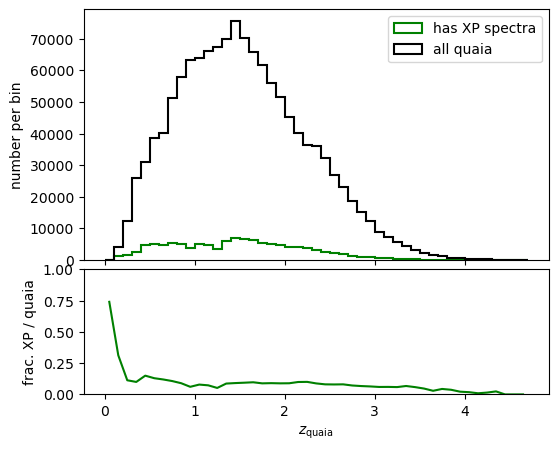

In [9]:
color_quaia = 'black'
color_xp = 'green'
bin_width = 0.1
bin_edges = np.arange(0, np.max(tab_quaia['redshift_quaia']) + bin_width, bin_width)
count_xp, _ = np.histogram(tab_has_xp['redshift_quaia'], bins=bin_edges)
count_quaia, _ = np.histogram(tab_quaia['redshift_quaia'], bins=bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
frac = np.where(count_quaia > 0, count_xp / count_quaia, np.nan)

fig = plt.figure(figsize=(6, 5))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)
plt.setp(ax_top.get_xticklabels(), visible=False)

ax_top.hist(tab_has_xp['redshift_quaia'], bins=bin_edges, histtype='step', label='has XP spectra', color=color_xp, linewidth=1.5)
ax_top.hist(tab_quaia['redshift_quaia'], bins=bin_edges, histtype='step', label='all quaia', color=color_quaia, linewidth=1.5)
ax_top.set_ylabel('number per bin')
ax_top.legend()

ax_bot.plot(bin_centers, frac, color=color_xp, linewidth=1.5)
ax_bot.set_xlabel(r'$z_{\rm quaia}$')
ax_bot.set_ylabel('frac. XP / quaia')
ax_bot.set_ylim(0.0, 1)
plt.show()


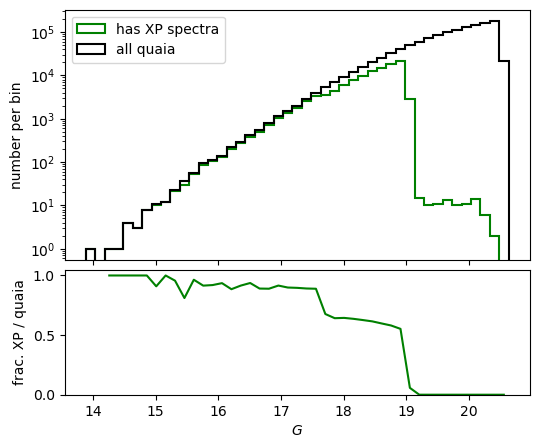

In [10]:
bin_width = 0.15
bin_edges = np.arange(np.min(tab_quaia[col_G]), np.max(tab_quaia[col_G]) + bin_width, bin_width)
count_xp, _ = np.histogram(tab_has_xp[col_G], bins=bin_edges)
count_quaia, _ = np.histogram(tab_quaia[col_G], bins=bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
frac = np.where(count_quaia > 0, count_xp / count_quaia, np.nan)

fig = plt.figure(figsize=(6, 5))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)
plt.setp(ax_top.get_xticklabels(), visible=False)

ax_top.hist(tab_has_xp[col_G], bins=bin_edges, histtype='step', label='has XP spectra', 
            color=color_xp, linewidth=1.5)
ax_top.hist(tab_quaia[col_G], bins=bin_edges, histtype='step', label='all quaia', 
            color=color_quaia, linewidth=1.5)
ax_top.set_ylabel('number per bin')
ax_top.set_yscale('log')
ax_top.legend()

ax_bot.plot(bin_centers, frac, color=color_xp, linewidth=1.5)
ax_bot.set_xlabel(r'$G$')
ax_bot.set_ylabel('frac. XP / quaia')
ax_bot.set_ylim(0, 1.05)
plt.show()


# Query spectra

## Single bright spectrum

In [ ]:
# Your source ID(s)
#bright one
source_ids = [1597998215189326080]

# Convert coefficients to calibrated spectra
# This downloads the coefficients and converts them automatically
calibrated_spectra, sampling = calibrate(source_ids, save_file=False)

# calibrated_spectra is a pandas DataFrame with columns:
# source_id, flux (array), flux_error (array)
# sampling is the wavelength array (in nm)

print("Flux shape:", calibrated_spectra['flux'][0].shape)


Flux shape: (343,) to path: ./output_spectra.csv         0/1 [00:00<?, ?spec/s]


In [12]:
calibrated_spectra.keys()

Index(['source_id', 'flux', 'flux_error'], dtype='object')

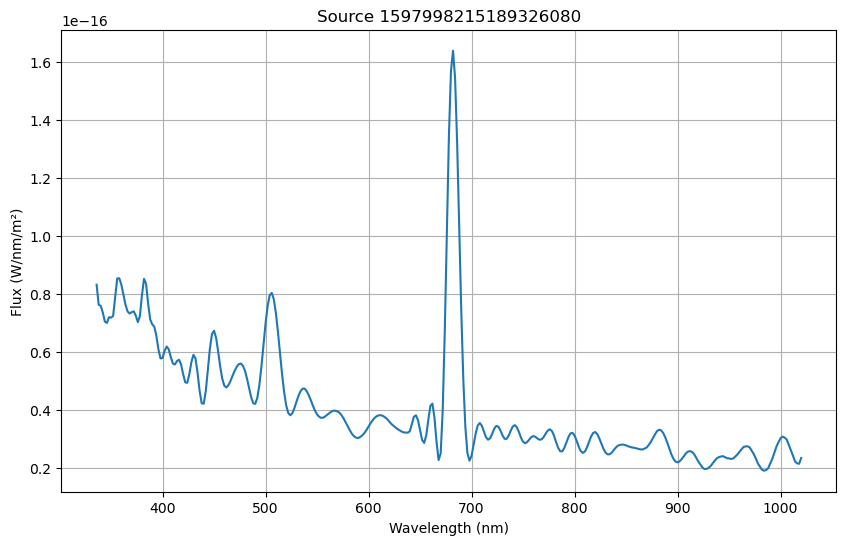

In [13]:

# Plot it
plt.figure(figsize=(10, 6))
plt.plot(sampling, calibrated_spectra['flux'][0])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux (W/nm/m²)')
plt.title(f'Source {source_ids[0]}')
plt.grid(True)
plt.show()

## Redshift range

In [14]:
from astroquery.gaia import Gaia

col_G = 'phot_g_mean_mag'
# Pick brightest source with XP spectra per redshift bin (9 bins up to z=4.5)
z_edges = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5]
ids_to_fetch = []
z_bin_labels = []
for i in range(9):
    mask = (tab_has_xp['redshift_quaia'] >= z_edges[i]) & (tab_has_xp['redshift_quaia'] < z_edges[i+1])
    if np.any(mask):
        masked_idx = np.where(mask)[0]
        idx = masked_idx[np.argmin(tab_has_xp[col_G][masked_idx])]
        ids_to_fetch.append(tab_has_xp['source_id'][idx])
        z_bin_labels.append(f'{z_edges[i]:.1f} $\leq z <$ {z_edges[i+1]:.1f}')
    else:
        ids_to_fetch.append(None)
        z_bin_labels.append(f'{z_edges[i]:.1f} $\leq z <$ {z_edges[i+1]:.1f} (no source)')

ids_list = [x for x in ids_to_fetch if x is not None]
bin_of_fetched = [i for i in range(9) if ids_to_fetch[i] is not None]
print(f'Fetching XP spectra for {len(ids_list)} sources (one per redshift bin)')

Fetching XP spectra for 9 sources (one per redshift bin)


In [ ]:
calibrated_spectra, sampling = calibrate(ids_list, save_file=False)

/var/folders/r3/x5f9h97x5yxcdy7qv3t1pr7m0000gn/T/ipykernel_78620/297036860.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


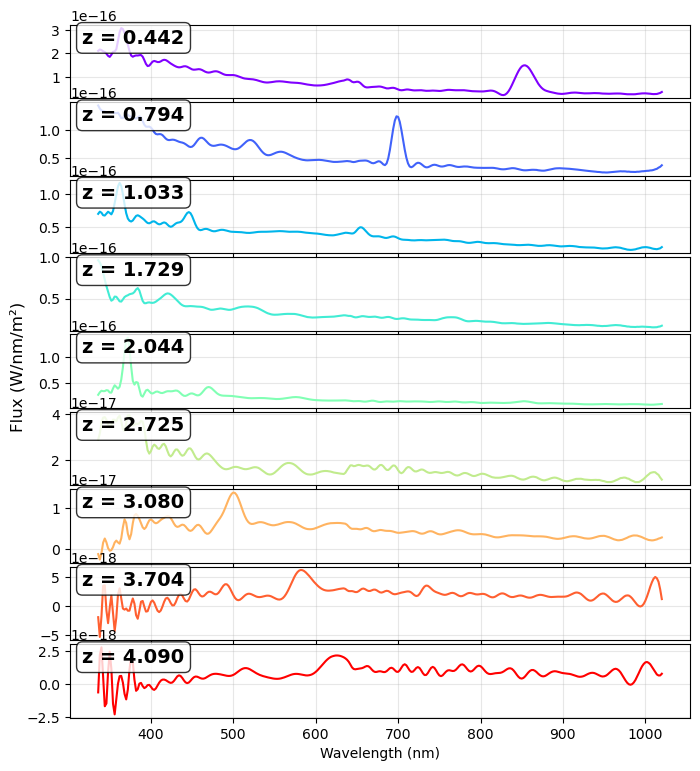

In [34]:
# Plot all in subplots with rainbow colors and redshift labels
import pandas as pd

# Get redshift for each spectrum by joining with tab_quaia
calibrated_spectra_df = calibrated_spectra.copy()
# Convert source_id to match type if needed
tab_quaia_df = tab_quaia.to_pandas()
redshift_dict = dict(zip(tab_quaia_df['source_id'], tab_quaia_df['redshift_quaia']))
calibrated_spectra_df['redshift'] = calibrated_spectra_df['source_id'].map(redshift_dict)

# Sort by redshift for better color progression
calibrated_spectra_df = calibrated_spectra_df.sort_values('redshift').reset_index(drop=True)

# Determine subplot layout - one row per spectrum, wide plots
n_spectra = len(calibrated_spectra_df)
n_rows = n_spectra
n_cols = 1

# Create figure with subplots - wide and short plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 1*n_spectra), 
                         sharex=True, gridspec_kw={'hspace': 0.05})
if n_spectra == 1:
    axes = np.array([axes])
axes = axes.flatten()

# Create rainbow colormap
colors = plt.cm.rainbow(np.linspace(0, 1, n_spectra))

# Plot each spectrum in its own subplot
for idx, (row_idx, row) in enumerate(calibrated_spectra_df.iterrows()):
    ax = axes[idx]
    z = row['redshift']
    
    ax.plot(sampling, row['flux'], color=colors[idx], linewidth=1.5)
    
    # Add z label in the plot box, bigger font
    ax.text(0.02, 0.95, f'z = {z:.3f}', transform=ax.transAxes, 
            fontsize=14, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.grid(True, alpha=0.3)

# Add single y-axis label for entire figure
fig.supylabel('Flux (W/nm/m²)', fontsize=12, y=0.5, x=0.05)
axes[-1].set_xlabel('Wavelength (nm)', fontsize=10)

plt.tight_layout()
plt.show()


In [26]:
print('hi')

hi


# grab some ra decs for images 

In [17]:
tab_select = tab_quaia[(tab_quaia[col_G]>18)&(tab_quaia[col_G]<19)&(tab_quaia['redshift_quaia']<0.8)]

In [18]:
tab_select['ra', 'dec', 'phot_g_mean_mag', 'redshift_quaia']

ra,dec,phot_g_mean_mag,redshift_quaia
deg,deg,mag,
float64,float64,float32,float64
45.20391785007929,0.9113096392855202,18.18146,0.669161423194202
44.1957090998565,1.2303609927166672,18.253172,0.17577782273292542
45.41331735274704,1.7497082192289903,18.678919,0.20832006672378364
45.253642525314866,1.8246709955842313,18.696598,0.5947461128234863
44.4826091153557,1.7434893915458203,18.590042,0.28144925832748413
44.70800296894258,1.8736280359890969,18.366703,0.6084240674972534
46.23617733991125,2.188245938511342,18.59145,0.2552449107170105
47.05882558041416,2.573103684344736,18.316292,0.5731565952301025


In [19]:
tab_select['ra', 'dec']

ra,dec
deg,deg
float64,float64
45.20391785007929,0.9113096392855202
44.1957090998565,1.2303609927166672
45.41331735274704,1.7497082192289903
45.253642525314866,1.8246709955842313
44.4826091153557,1.7434893915458203
44.70800296894258,1.8736280359890969
46.23617733991125,2.188245938511342
47.05882558041416,2.573103684344736
